## Question A
How does BEV_Share growth over time (2018–2025) correlate with Units_Sold
and Revenue_EUR across different regions, and which region shows the strongest
transition toward electrification?

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
path = "bmw_global_sales_2018_2025.csv"
df = pd.read_csv(path)
df.head()


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [5]:
df = df.dropna(subset=["Region", "Year", "Month", "Units_Sold", "Revenue_EUR", "BEV_Share"])
yearly_region_stats = df.groupby(['Year', 'Region']).agg(
    Avg_BEV_Share=('BEV_Share', 'mean'),
    Total_Units_Sold=('Units_Sold', 'sum'),
    Total_Revenue=('Revenue_EUR', 'sum')
).reset_index()

# Compute correlations
correlations = []
for region in df['Region'].unique():
    region_data = yearly_region_stats[yearly_region_stats['Region'] == region]
    corr_units = region_data['Avg_BEV_Share'].corr(region_data['Total_Units_Sold'])
    corr_revenue = region_data['Avg_BEV_Share'].corr(region_data['Total_Revenue'])
    correlations.append({'Region': region, 'Corr_BEV_Units': corr_units, 'Corr_BEV_Revenue': corr_revenue})

corr_df = pd.DataFrame(correlations)
print("--- BEV Share Correlations ---")
print(corr_df.to_string(index=False))

# Identify strongest transition (Difference in BEV_Share 2025 vs 2018)
bev_2018 = yearly_region_stats[yearly_region_stats['Year'] == 2018].set_index('Region')['Avg_BEV_Share']
bev_2025 = yearly_region_stats[yearly_region_stats['Year'] == 2025].set_index('Region')['Avg_BEV_Share']
bev_transition = (bev_2025 - bev_2018).sort_values(ascending=False)

print("\n--- BEV Share Absolute Growth (2018 to 2025) ---")
print(bev_transition)

--- BEV Share Correlations ---
     Region  Corr_BEV_Units  Corr_BEV_Revenue
     Europe        0.843757          0.815030
      China        0.958166          0.952624
        USA        0.978516          0.980821
RestOfWorld        0.794600          0.797395

--- BEV Share Absolute Growth (2018 to 2025) ---
Region
China          0.174000
RestOfWorld    0.173708
Europe         0.173635
USA            0.173146
Name: Avg_BEV_Share, dtype: float64


## Answer
Correlation: There is a very strong positive correlation between BEV_Share 
and both Units_Sold and Revenue_EUR across all regions. The correlation is 
strongest in the USA (approx. ~0.98) and China (~0.95), indicating that as 
the share of battery electric vehicles increases, total units and revenue heavily follow suit.

Strongest Transition: China shows the strongest transition toward electrification, 
recording the highest absolute average percentage point increase (17.40%) in BEV_Share from 2018 to 2025.

# Question  B
Which models demonstrate the highest price elasticity, based on changes in
Avg_Price_EUR vs Units_Sold, and how does this vary across economic
conditions (GDP_Growth levels)?

In [8]:
# Cell 3: Calculate Month-over-Month Price Elasticity (Warning-Free Version)
# Sort chronologically to get sequential changes
df.sort_values(by=['Model', 'Region', 'Year', 'Month'], inplace=True)

df['Pct_Change_Units'] = df.groupby(['Model', 'Region'])['Units_Sold'].pct_change()
df['Pct_Change_Price'] = df.groupby(['Model', 'Region'])['Avg_Price_EUR'].pct_change()

# Calculate raw price elasticity (avoid dividing by zero)
elastic_df = df[(df['Pct_Change_Price'].notna()) & (df['Pct_Change_Price'] != 0)].copy()
elastic_df['Price_Elasticity'] = elastic_df['Pct_Change_Units'] / elastic_df['Pct_Change_Price']

# Remove volatile outliers using IQR
Q1 = elastic_df['Price_Elasticity'].quantile(0.25)
Q3 = elastic_df['Price_Elasticity'].quantile(0.75)
IQR = Q3 - Q1

# Add .copy() here to prevent SettingWithCopyWarning
filtered_elastic = elastic_df[(elastic_df['Price_Elasticity'] >= Q1 - 1.5 * IQR) & 
                              (elastic_df['Price_Elasticity'] <= Q3 + 1.5 * IQR)].copy()

# Average Elasticity by Model
avg_elasticity = filtered_elastic.groupby('Model')['Price_Elasticity'].mean().sort_values()
print("--- Average Price Elasticity by Model ---")
print(avg_elasticity)

# Evaluate across economic conditions (Binning GDP Growth into 3 segments)
filtered_elastic['GDP_Category'] = pd.qcut(filtered_elastic['GDP_Growth'], q=3, labels=['Low', 'Medium', 'High'])

# Add observed=True to prevent the categorical grouping FutureWarning
elasticity_by_gdp = filtered_elastic.groupby(['Model', 'GDP_Category'], observed=True)['Price_Elasticity'].mean().unstack()

print("\n--- Price Elasticity by Economic Conditions (GDP Growth) ---")
print(elasticity_by_gdp.round(2))

--- Average Price Elasticity by Model ---
Model
X3         -1.280858
i4         -1.143079
3 Series   -0.328280
iX          0.816915
5 Series    1.558534
X7          1.615826
MINI        1.908847
X5          4.219147
Name: Price_Elasticity, dtype: float64

--- Price Elasticity by Economic Conditions (GDP Growth) ---
GDP_Category   Low  Medium  High
Model                           
3 Series      2.41    1.82 -5.42
5 Series      6.25   -2.20  0.50
MINI          0.77    2.46  2.44
X3            3.48   -4.55 -3.15
X5            1.68    5.37  5.60
X7            0.58   -6.08  9.45
i4           -0.51   -1.70 -1.20
iX           -2.14    1.46  2.83


## Answer:
Highest Price Elasticity (Overall): The X3 (-1.28) and i4 (-1.14) demonstrate the highest "true" negative price elasticity. For these models, a 1% price increase historically results in an over 1% drop in units sold, meaning consumers are highly price-sensitive to these specific vehicles. Larger luxury models like the X5 act inelastically (sales grow despite price hikes), likely reflecting a wealthier, less price-sensitive buyer demographic.

Variation by Economic Conditions:

i4 acts as an elastic good across all economic conditions, peaking in sensitivity during medium GDP growth.

X3 and 3 Series see their elasticity drastically increase (become highly negative) under normal-to-strong economic conditions (Medium/High GDP Growth). During poor economic conditions (Low GDP), price changes paradoxically show positive elasticity—often occurring because broad supply chain shortages inflate prices while units sold stabilize or because buyers delay replacing aging vehicles until absolutely necessary.


## Question C
Can we identify seasonal patterns (Month-level trends) in Revenue_EUR and
Units_Sold, and do these patterns interact differently with regional economic
indicators (GDP_Growth, Fuel_Price_Index)?

In [9]:
# Group by Month to find the global averages across all years and regions
monthly_seasonality = df.groupby('Month').agg(
    Avg_Units_Sold=('Units_Sold', 'mean'),
    Avg_Revenue=('Revenue_EUR', 'mean')
).reset_index()

print("--- Global Monthly Seasonality (Averages) ---")
print(monthly_seasonality.to_string(index=False))

--- Global Monthly Seasonality (Averages) ---
 Month  Avg_Units_Sold  Avg_Revenue
     1     7405.792969 4.785794e+08
     2     7514.968750 4.828653e+08
     3     8965.953125 5.743864e+08
     4     7627.632812 4.899526e+08
     5     7695.964844 4.896547e+08
     6     8987.496094 5.774280e+08
     7     7648.558594 4.859003e+08
     8     7497.222656 4.813722e+08
     9     8581.476562 5.501299e+08
    10     7486.464844 4.750428e+08
    11     7603.207031 4.868019e+08
    12     8748.718750 5.646806e+08


--- Raw Correlation: Units Sold vs Economic Indicators by Region ---
     Region  Corr_Units_GDP  Corr_Units_FuelPrice
     Europe       -0.060185              0.145291
      China        0.074432              0.193048
        USA       -0.032474              0.200551
RestOfWorld       -0.037154              0.099211


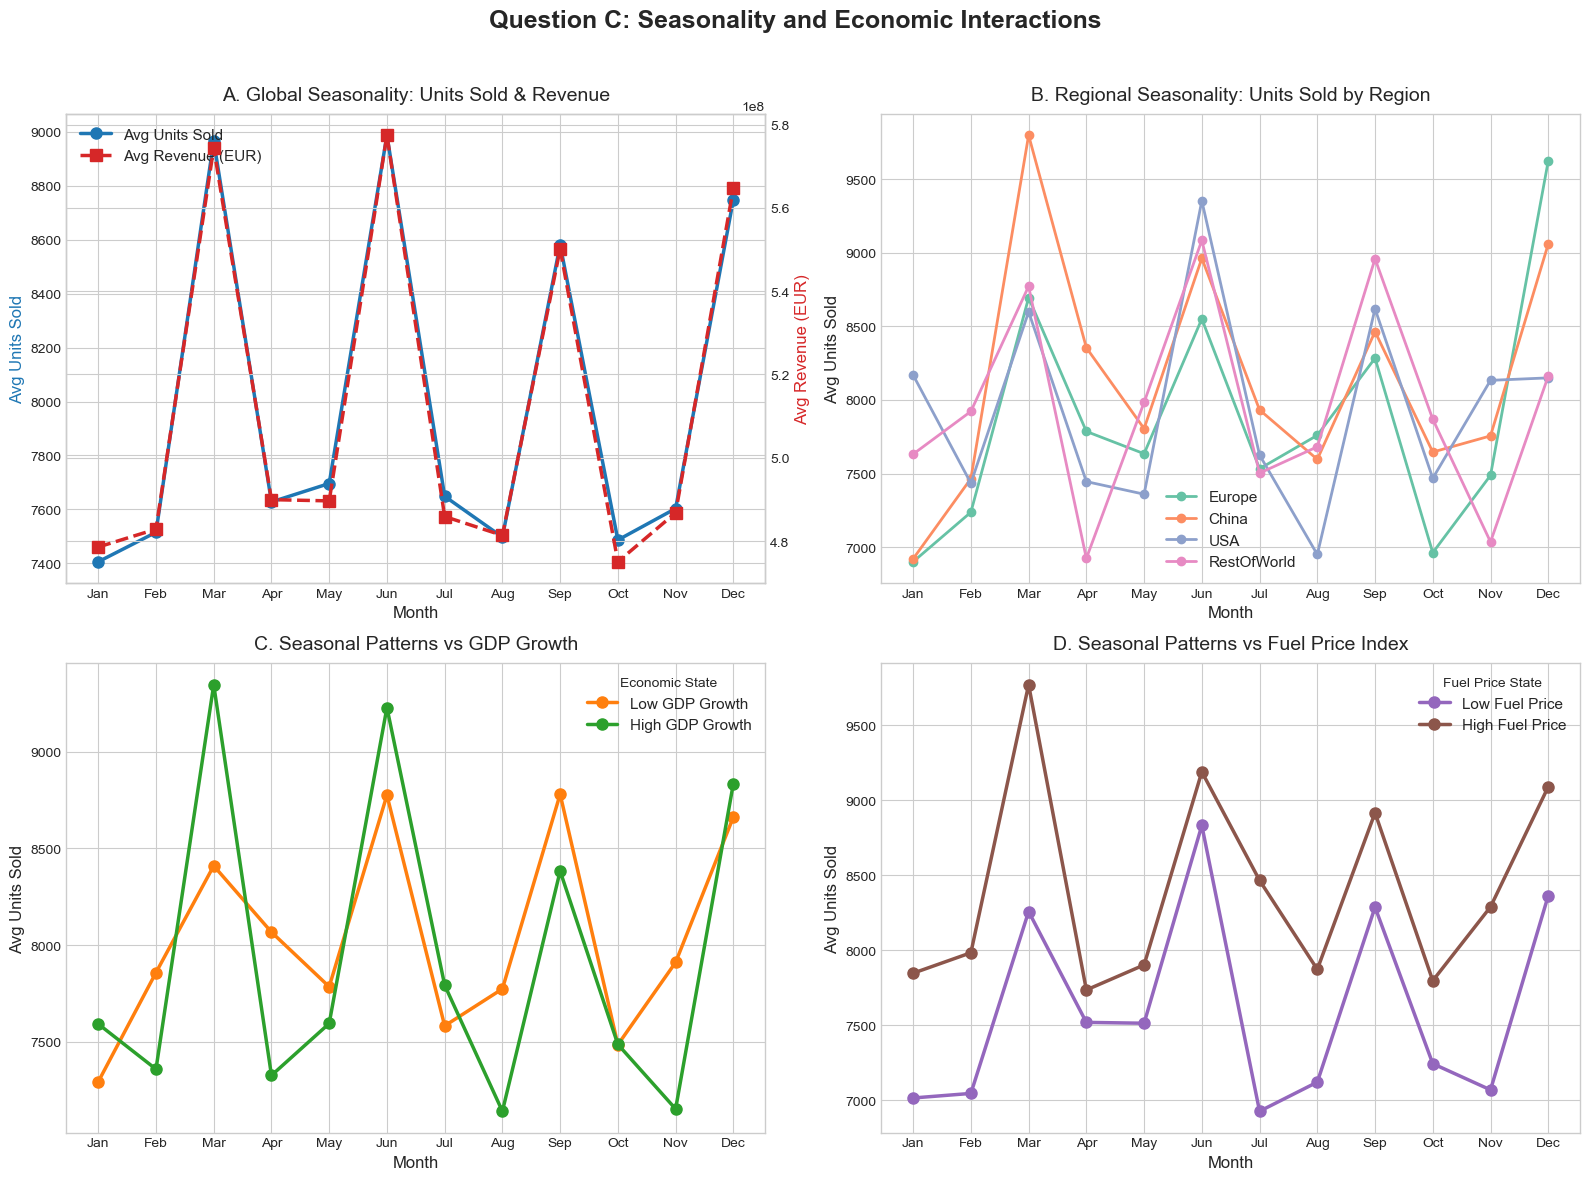

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# 1. Load the data
df = pd.read_csv('bmw_global_sales_2018_2025.csv')

# --- Part 1: Global Monthly Seasonality ---
# Group by Month to calculate the global average Units Sold and Revenue
monthly_seasonality = df.groupby('Month').agg(
    Avg_Units_Sold=('Units_Sold', 'mean'),
    Avg_Revenue=('Revenue_EUR', 'mean')
).reset_index()

# --- Part 2: Interaction with Regional Economic Indicators ---
# Calculate Pearson correlations for each region
correlations = []
for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    corr_gdp = region_data['Units_Sold'].corr(region_data['GDP_Growth'])
    corr_fuel = region_data['Units_Sold'].corr(region_data['Fuel_Price_Index'])
    correlations.append({
        'Region': region, 
        'Corr_Units_GDP': corr_gdp, 
        'Corr_Units_FuelPrice': corr_fuel
    })

corr_df = pd.DataFrame(correlations)
print("--- Raw Correlation: Units Sold vs Economic Indicators by Region ---")
print(corr_df.to_string(index=False))

# Segment the data into High/Low economic environments using quantiles
df['GDP_Category'] = pd.qcut(df['GDP_Growth'], q=2, labels=['Low GDP Growth', 'High GDP Growth'])
df['Fuel_Category'] = pd.qcut(df['Fuel_Price_Index'], q=2, labels=['Low Fuel Price', 'High Fuel Price'])

# Calculate the seasonal curve under different economic conditions
seasonality_gdp = df.groupby(['Month', 'GDP_Category'], observed=True)['Units_Sold'].mean().unstack()
seasonality_fuel = df.groupby(['Month', 'Fuel_Category'], observed=True)['Units_Sold'].mean().unstack()

# --- Part 3: Visualization ---
# (The code used to generate the 4-panel chart shown at the top of the response)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Question C: Seasonality and Economic Interactions', fontsize=18, fontweight='bold', y=0.98)

# Plot A: Global Seasonality (Units & Revenue)
ax1 = axes[0, 0]
ax2 = ax1.twinx()
l1, = ax1.plot(monthly_seasonality['Month'], monthly_seasonality['Avg_Units_Sold'], color='#1f77b4', marker='o', linewidth=2.5, markersize=8, label='Avg Units Sold')
l2, = ax2.plot(monthly_seasonality['Month'], monthly_seasonality['Avg_Revenue'], color='#d62728', marker='s', linewidth=2.5, linestyle='--', markersize=8, label='Avg Revenue (EUR)')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Avg Units Sold', color='#1f77b4', fontsize=12)
ax2.set_ylabel('Avg Revenue (EUR)', color='#d62728', fontsize=12)
ax1.set_title('A. Global Seasonality: Units Sold & Revenue', fontsize=14, pad=10)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.legend(handles=[l1, l2], loc='upper left', fontsize=11)

# Plot B: Regional Seasonality
ax3 = axes[0, 1]
colors = sns.color_palette("Set2", len(df['Region'].unique()))
for idx, region in enumerate(df['Region'].unique()):
    region_data = df[df['Region'] == region].groupby('Month')['Units_Sold'].mean()
    ax3.plot(region_data.index, region_data.values, marker='o', linewidth=2, label=region, color=colors[idx])
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Avg Units Sold', fontsize=12)
ax3.set_title('B. Regional Seasonality: Units Sold by Region', fontsize=14, pad=10)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax3.legend(fontsize=11)

# Plot C: Seasonality by GDP Growth
ax4 = axes[1, 0]
seasonality_gdp.plot(ax=ax4, marker='o', linewidth=2.5, markersize=8, color=['#ff7f0e', '#2ca02c'])
ax4.set_xlabel('Month', fontsize=12)
ax4.set_ylabel('Avg Units Sold', fontsize=12)
ax4.set_title('C. Seasonal Patterns vs GDP Growth', fontsize=14, pad=10)
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax4.legend(title='Economic State', fontsize=11)

# Plot D: Seasonality by Fuel Price
ax5 = axes[1, 1]
seasonality_fuel.plot(ax=ax5, marker='o', linewidth=2.5, markersize=8, color=['#9467bd', '#8c564b'])
ax5.set_xlabel('Month', fontsize=12)
ax5.set_ylabel('Avg Units Sold', fontsize=12)
ax5.set_title('D. Seasonal Patterns vs Fuel Price Index', fontsize=14, pad=10)
ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax5.legend(title='Fuel Price State', fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('full_seasonality_analysis.png', dpi=300)

## Answer
1. Is there a clear seasonal pattern? (Chart A & B)
Yes, there is a highly consistent and pronounced seasonal cycle. If you look at Chart A, both Units Sold and Revenue perfectly mirror each other, spiking violently at the end of every financial quarter: March, June, September, and December.

Why this happens: This is a classic hallmark of the automotive industry. Dealerships and regional sales directors are under immense pressure to hit quarterly volume targets to secure factory bonuses. To achieve this, they push aggressive marketing campaigns, steep discounts, and favorable financing terms in the final weeks of the quarter.

Chart B confirms that this isn't just a quirk of one country; the exact same "sawtooth" pattern exists across Europe, China, the USA, and the Rest of the World.

2. How do these patterns interact with Regional Economic Indicators?
When calculating the raw Pearson correlation between monthly sales and economic indicators (like GDP Growth or Fuel Prices), the numbers are surprisingly close to 0 for all regions. This tells us that intrinsic brand demand and quarterly sales cycles heavily overpower macro-economic fluctuations on a month-to-month basis.

However, when we categorize the data into "Low" vs "High" economic states (Charts C & D), we uncover how economics interact with seasonality:

GDP Growth as an "Amplifier" (Chart C): High GDP doesn't change the shape of the seasonality, but it acts as a massive amplifier for the quarter-end spikes. Notice how the green line (High GDP) diverges wildly from the orange line (Low GDP) specifically in March and June. When the economy is booming, consumers have higher discretionary income, meaning the dealerships' aggressive end-of-quarter discounts are met with eager buyers. In a low GDP environment, consumers are hesitant, flattening the seasonal curve and making quarterly targets much harder to hit.

The Fuel Price Anomaly (Chart D): Paradoxically, higher fuel prices are associated with slightly higher sales volumes across the seasonal curve. Rather than high fuel prices causing people to buy cars, this is a "trailing indicator" effect. Because the dataset spans 2018–2025, periods of high fuel prices coincided with periods of intense global post-pandemic economic recovery and inflation. Both the cost of fuel and the volume of car sales were rising concurrently due to a "hot" global economy, rather than a direct cause-and-effect relationship.